In [91]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, gaussian_kde
from scipy.spatial.distance import jensenshannon

In [92]:
master_df = pd.read_csv('master_df_with_deltas.csv')

In [93]:
questions = master_df['Question'].unique()

In [94]:
master_df.columns

Index(['ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'BeforeResponse', 'AfterNumber', 'AfterResponse',
       'GROUP', 'RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER',
       'AGE', 'run_0', 'run_1', 'run_2', 'run_3', 'run_4', 'run_5', 'run_6',
       'run_7', 'run_8', 'run_9', 'delta_observed', 'delta_0', 'delta_1',
       'delta_2', 'delta_3', 'delta_4', 'delta_5', 'delta_6', 'delta_7',
       'delta_8', 'delta_9', 'delta_mean_llm', 'delta_stf_llm', 'delta_diff_0',
       'delta_diff_1', 'delta_diff_2', 'delta_diff_3', 'delta_diff_4',
       'delta_diff_5', 'delta_diff_6', 'delta_diff_7', 'delta_diff_8',
       'delta_diff_9'],
      dtype='object')

In [95]:
master_df["llm_avg"] = master_df[[f"run_{seed}" for seed in range(0,10)]].mean(axis=1)

In [96]:
results = []
for question in questions:
    q_df = master_df[master_df['Question'] == question]
    human_shift  = q_df['delta_observed']
    
    ks_stats, ks_pvals = [], []
    w_dists, js_divs = [], []

    for i in range(10):
        sim_shift = q_df[f'delta_{i}']
    
        ks_stat, ks_pval = ks_2samp(human_shift, sim_shift)
        w_dist = wasserstein_distance(human_shift, sim_shift)
        # choose shared bins, e.g. 0,1,2,...,10
        bins = np.arange(-10, 11)  # or np.arange(0, 11+1) if using np.histogram

        # histograms -> counts per bin
        h_counts, _ = np.histogram(human_shift, bins=bins, density=False)
        l_counts, _ = np.histogram(sim_shift, bins=bins, density=False)

        # convert to probabilities
        p_h = h_counts / h_counts.sum()
        p_l = l_counts / l_counts.sum()

        js = jensenshannon(p_h, p_l)
        
        ks_stats.append(ks_stat)
        ks_pvals.append(ks_pval)
        w_dists.append(w_dist)
        js_divs.append(js)
    results.append({
        'question': question,
        'human_mean_shift': human_shift.mean(),
        'llm_mean_shift': q_df['delta_mean_llm'].mean(),
        'ks_D_mean': np.mean(ks_stats),
        'ks_D_sd': np.std(ks_stats),
        'ks_p_mean': np.mean(ks_pvals),
        'wasserstein_mean': np.mean(w_dists),
        'wasserstein_sd': np.std(w_dists),
        'js_mean': np.mean(js_divs),
        'js_sd': np.std(js_divs),
    })
results_df = pd.DataFrame(results)

In [97]:
results_df.head()

,question,human_mean_shift,llm_mean_shift,ks_D_mean,ks_D_sd,ks_p_mean,wasserstein_mean,wasserstein_sd,js_mean,js_sd
0,Q1,1.346939,-0.292245,0.469592,0.035081,2.043373e-39,2.044082,0.124537,0.551644,0.015196
1,Q2A,-1.564870,-0.459281,0.411976,0.037066,1.642743e-31,1.660479,0.082082,0.512478,0.026938
2,Q2B,1.205589,0.483633,0.292216,0.030963,8.867119e-13,1.092016,0.062876,0.386067,0.027188
3,Q2C,0.351515,0.819192,0.284848,0.033244,1.308110e-10,1.494747,0.098876,0.444909,0.026697
4,Q2D,1.234592,0.629225,0.323459,0.029314,1.961105e-18,1.288867,0.062503,0.460107,0.026100


In [98]:
results_df['no_sig_diff'] = results_df['ks_p_mean'] > 0.05

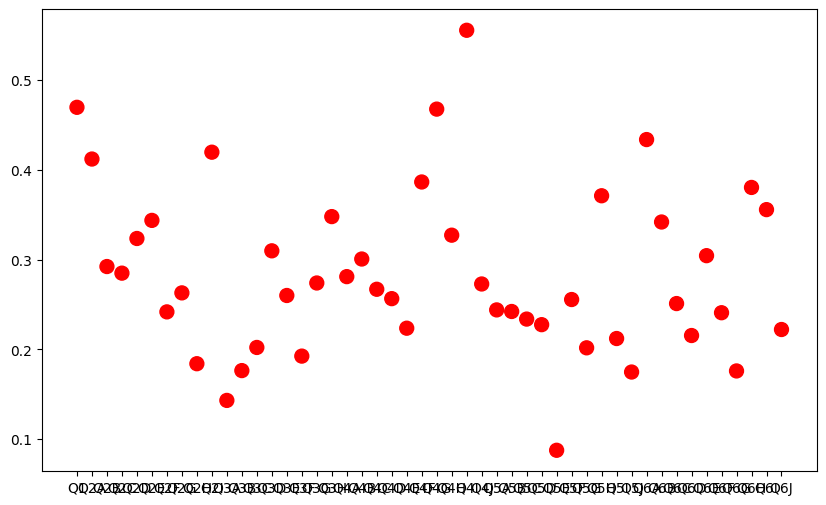

In [99]:
# show in graph which questions had no significant KS
plt.figure(figsize=(10, 6))
plt.scatter(results_df['question'], results_df['ks_D_mean'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))

In [100]:
results = []
for question in questions:
    q_df = master_df[master_df['Question'] == question]
    human_after  = q_df['AfterNumber']
    
    ks_stats, ks_pvals = [], []
    w_dists, js_divs = [], []

    for i in range(10):
        llm_after = q_df[f'run_{i}']
    
        ks_stat, ks_pval = ks_2samp(human_after, llm_after)
        w_dist = wasserstein_distance(human_after, llm_after)
        # choose shared bins, e.g. 0,1,2,...,10
        bins = np.arange(0, 11)  # or np.arange(0, 11+1) if using np.histogram

        # histograms -> counts per bin
        h_counts, _ = np.histogram(human_after, bins=bins, density=False)
        l_counts, _ = np.histogram(llm_after, bins=bins, density=False)

        # convert to probabilities
        p_h = h_counts / h_counts.sum()
        p_l = l_counts / l_counts.sum()

        js = jensenshannon(p_h, p_l)
        
        ks_stats.append(ks_stat)
        ks_pvals.append(ks_pval)
        w_dists.append(w_dist)
        js_divs.append(js)
    results.append({
        'question': question,
        'human_mean_shift': human_after.mean(),
        'llm_mean_shift': q_df['llm_avg'].mean(),
        'ks_D_mean': np.mean(ks_stats),
        'ks_D_sd': np.std(ks_stats),
        'ks_p_mean': np.mean(ks_pvals),
        'ks_p_sd': np.std(ks_pvals),
        'wasserstein_mean': np.mean(w_dists),
        'wasserstein_sd': np.std(w_dists),
        'js_mean': np.mean(js_divs),
        'js_sd': np.std(js_divs),
    })
results_df = pd.DataFrame(results)

In [101]:
results_df.head()

,question,human_mean_shift,llm_mean_shift,ks_D_mean,ks_D_sd,ks_p_mean,ks_p_sd,wasserstein_mean,wasserstein_sd,js_mean,js_sd
0,Q1,5.877551,4.238367,0.319388,0.022657,2.761837e-17,8.285307e-17,1.639184,0.121028,0.339100,0.027639
1,Q2A,3.419162,4.524750,0.301796,0.059706,8.602248e-10,2.552453e-09,1.273653,0.147422,0.324715,0.041024
2,Q2B,8.738523,8.016567,0.264072,0.092655,1.180893e-05,3.300855e-05,0.722754,0.124387,0.185057,0.031603
3,Q2C,6.131313,6.598990,0.187677,0.018124,3.444620e-07,5.061046e-07,0.719394,0.101628,0.282170,0.050744
4,Q2D,7.618290,7.012922,0.196421,0.034900,4.541067e-05,1.326224e-04,0.691650,0.088805,0.244104,0.027646


In [102]:
results_df['no_sig_diff'] = results_df['ks_p_mean']  > 0.05
results_df['wasserstein_close'] = results_df['wasserstein_mean']  < 0.3
results_df['js_low'] = results_df['js_mean'] < 0.2

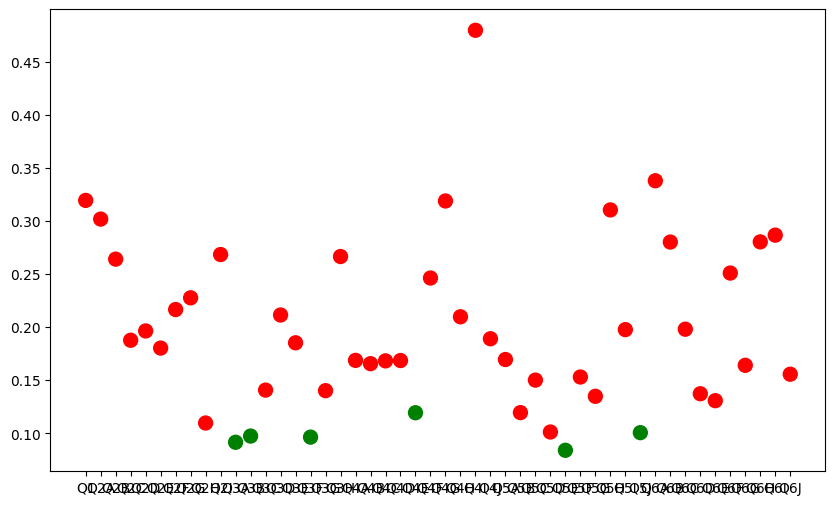

In [103]:
# show in graph which questions had no significant KS
plt.figure(figsize=(10, 6))
plt.scatter(results_df['question'], results_df['ks_D_mean'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))


In [104]:
# print questions where no significant difference was found
for idx, row in results_df.iterrows():
    if row['no_sig_diff']:
        print(f"Question {row['question']} shows no significant difference (KS p={row['ks_p_mean']:.3f})")

Question Q3A shows no significant difference (KS p=0.196)
Question Q3B shows no significant difference (KS p=0.055)
Question Q3F shows no significant difference (KS p=0.072)
Question Q4E shows no significant difference (KS p=0.058)
Question Q5E shows no significant difference (KS p=0.242)
Question Q5J shows no significant difference (KS p=0.245)


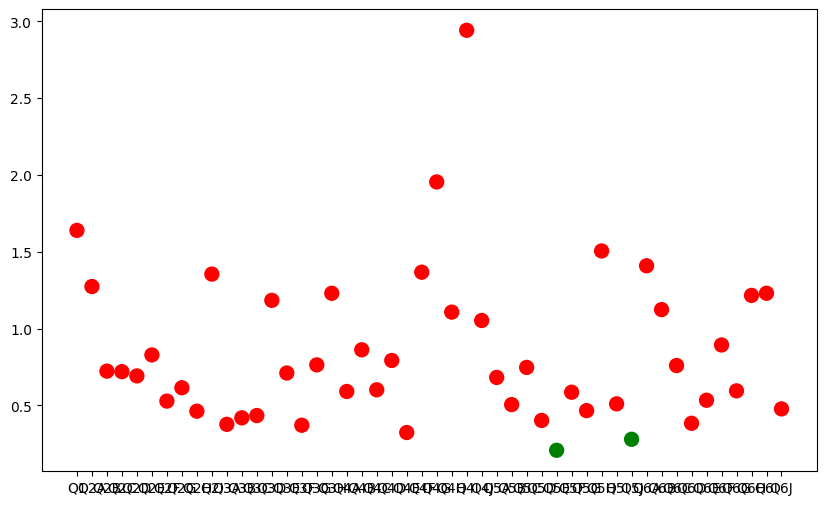

In [105]:
# show in graph which questions had no significant KS
plt.figure(figsize=(10, 6))

plt.scatter(results_df['question'], results_df['wasserstein_mean'], c=results_df['wasserstein_close'].map({True: 'green', False: 'red'}), s=100,)

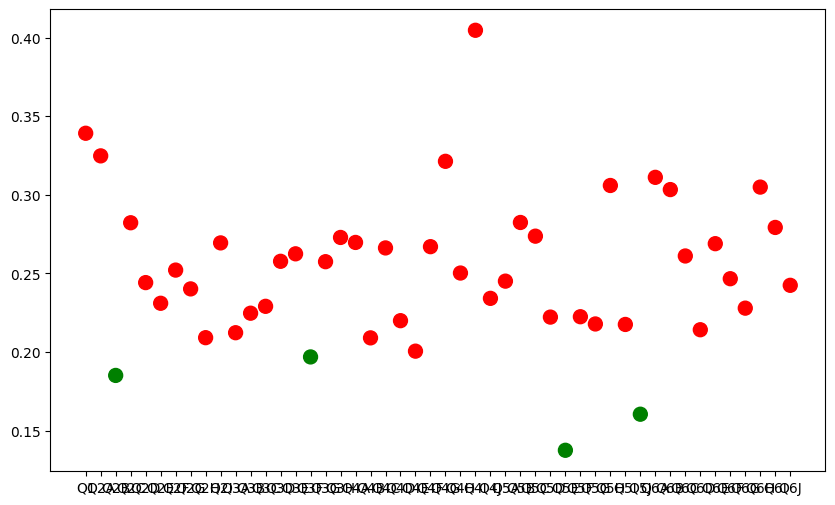

In [106]:
plt.figure(figsize=(10, 6))

plt.scatter(results_df['question'], results_df['js_mean'], c=results_df['js_low'].map({True: 'green', False: 'red'}), s=100,)

In [107]:
best_sims = results_df.sort_values('ks_p_mean', ascending=False).head(10)

In [108]:
best_sims[['question', 'ks_D_mean', 'ks_p_mean', 'wasserstein_mean', 'js_mean']]

,question,ks_D_mean,ks_p_mean,wasserstein_mean,js_mean
37,Q5J,0.100612,0.244554,0.278980,0.160385
32,Q5E,0.084016,0.242139,0.207407,0.137446
10,Q3A,0.091558,0.196199,0.376407,0.212226
15,Q3F,0.096414,0.072094,0.370518,0.196826
22,Q4E,0.119368,0.057762,0.323123,0.200494
11,Q3B,0.097414,0.054543,0.418534,0.224639
8,Q2H,0.109703,0.035216,0.461980,0.209072
29,Q5B,0.119497,0.032557,0.504822,0.282347
12,Q3C,0.140702,0.029939,0.433678,0.229016
31,Q5D,0.101230,0.028871,0.401639,0.222163


In [109]:
best_sims['question'].tolist()

['Q5J', 'Q5E', 'Q3A', 'Q3F', 'Q4E', 'Q3B', 'Q2H', 'Q5B', 'Q3C', 'Q5D']

In [110]:
import scipy.stats

results = []
for question in questions:
    q_df = master_df[master_df['Question'] == question]
    human_after  = q_df['AfterNumber']
    
    t_stat_arr, p_val_arr, effect_size_arr = [], [], []

    for i in range(10):
        llm_after = q_df[f'run_{i}']

        t_stat, p_val = scipy.stats.ttest_rel(human_after, llm_after)
        effect_size = (human_after.mean() - llm_after.mean()) / np.std(human_after - llm_after)
        t_stat_arr.append(t_stat)
        p_val_arr.append(p_val)
        effect_size_arr.append(effect_size)


    results.append({
        'question': question,
        'human_mean_shift': human_after.mean(),
        'llm_mean_shift': q_df['llm_avg'].mean(),
        'ttest_stat_mean': np.mean(t_stat_arr),
        'ttest_p_mean': np.mean(p_val_arr),
        'effect_size_mean': np.mean(effect_size_arr),
        'ttest_stat_sd': np.std(t_stat_arr),
        'ttest_p_sd': np.std(p_val_arr),
        'effect_size_sd': np.std(effect_size_arr),
    })
results_df = pd.DataFrame(results)

In [111]:
results_df.head()

,question,human_mean_shift,llm_mean_shift,ttest_stat_mean,ttest_p_mean,effect_size_mean,ttest_stat_sd,ttest_p_sd,effect_size_sd
0,Q1,5.877551,4.238367,14.635137,1.049939e-32,0.661824,1.193112,3.148059e-32,0.053954
1,Q2A,3.419162,4.524750,-8.924649,1.414535e-13,-0.399122,0.810999,4.238319e-13,0.036269
2,Q2B,8.738523,8.016567,7.491836,1.937313e-09,0.335045,1.126245,5.679311e-09,0.050367
3,Q2C,6.131313,6.598990,-3.851949,4.156633e-03,-0.173307,1.022515,7.809722e-03,0.046005
4,Q2D,7.618290,7.012922,5.832863,1.167999e-06,0.260333,0.765919,3.043338e-06,0.034185


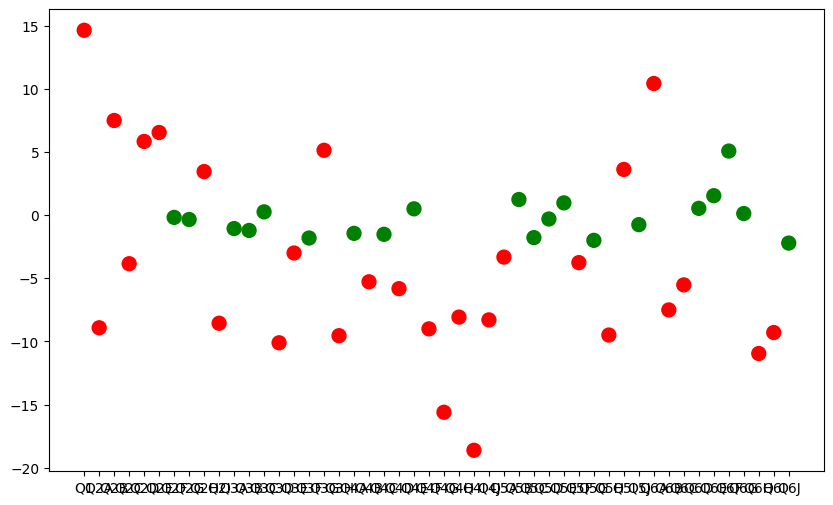

In [112]:
results_df['no_sig_diff'] = results_df['ttest_p_mean']  > 0.05
results_df['small_effect'] = results_df['effect_size_mean'].abs() < 0.2
# show in graph which questions had no significant t-test
plt.figure(figsize=(10, 6))
plt.scatter(results_df['question'], results_df['ttest_stat_mean'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))

In [113]:
# i want to report variability
group_df = master_df[master_df['Question'] == 'Q1']

group_dem = []
for group in range(1,41):
    g_df = group_df[group_df['GROUP'] == group]
    group_size = g_df.shape[0]
    dem = {}
    for col in ['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']:
        prop = [] 
        for val in g_df[col].unique():
            count = g_df[g_df[col] == val].shape[0]
            prop.append(count / group_size)
        diversity_index = sum(p**2 for p in prop)
        dem[col] = diversity_index
    group_dem.append({
        'group': group,
        **dem
    })

In [114]:
group_dem_df = pd.DataFrame(group_dem)
group_dem_df

,group,RACE,AGEBRACKET,EDUCATION,PARTYBEFORE,GENDER
0,1,0.448980,0.316327,0.438776,0.346939,0.510204
1,2,0.257812,0.289062,0.367188,0.507812,0.500000
2,3,0.301775,0.337278,0.301775,0.337278,0.502959
3,4,0.708333,0.291667,0.555556,0.347222,0.513889
4,5,0.621302,0.360947,0.526627,0.360947,0.502959
5,6,0.493333,0.315556,0.360000,0.342222,0.502222
6,7,0.621302,0.301775,0.857988,0.360947,0.502959
7,8,0.802469,0.382716,0.506173,0.358025,0.555556
8,9,0.422222,0.306667,0.360000,0.368889,0.608889
9,10,0.500000,0.397959,0.357143,0.377551,0.540816


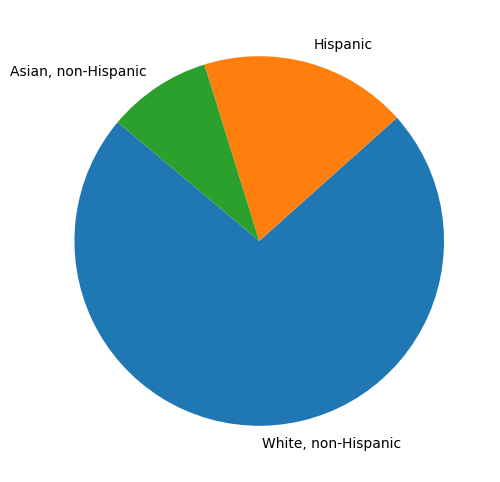

In [115]:
# visualise group 8 race diversity
vis = group_df[group_df['GROUP'] == 39]
plt.figure(figsize=(10,6))
s = vis["RACE"].value_counts()
plt.pie(s, labels=s.index, startangle=140)
plt.show()

In [116]:
master_df.columns

Index(['ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'BeforeResponse', 'AfterNumber', 'AfterResponse',
       'GROUP', 'RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER',
       'AGE', 'run_0', 'run_1', 'run_2', 'run_3', 'run_4', 'run_5', 'run_6',
       'run_7', 'run_8', 'run_9', 'delta_observed', 'delta_0', 'delta_1',
       'delta_2', 'delta_3', 'delta_4', 'delta_5', 'delta_6', 'delta_7',
       'delta_8', 'delta_9', 'delta_mean_llm', 'delta_stf_llm', 'delta_diff_0',
       'delta_diff_1', 'delta_diff_2', 'delta_diff_3', 'delta_diff_4',
       'delta_diff_5', 'delta_diff_6', 'delta_diff_7', 'delta_diff_8',
       'delta_diff_9', 'llm_avg'],
      dtype='object')

In [117]:
# i want to predict how far off the llm shift is with inputs of the before, after, and demographic information
import sklearn
from sklearn.model_selection import train_test_split

df = master_df[master_df['Question'] == 'Q1'].copy()
df.drop
df.columns

Index(['ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'BeforeResponse', 'AfterNumber', 'AfterResponse',
       'GROUP', 'RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER',
       'AGE', 'run_0', 'run_1', 'run_2', 'run_3', 'run_4', 'run_5', 'run_6',
       'run_7', 'run_8', 'run_9', 'delta_observed', 'delta_0', 'delta_1',
       'delta_2', 'delta_3', 'delta_4', 'delta_5', 'delta_6', 'delta_7',
       'delta_8', 'delta_9', 'delta_mean_llm', 'delta_stf_llm', 'delta_diff_0',
       'delta_diff_1', 'delta_diff_2', 'delta_diff_3', 'delta_diff_4',
       'delta_diff_5', 'delta_diff_6', 'delta_diff_7', 'delta_diff_8',
       'delta_diff_9', 'llm_avg'],
      dtype='object')

In [118]:
# preprocesses the dataset

#normalise all
# predicts  how far off the llm shift is from the human shift = afternumber - run_x

In [119]:
master_df['RACE'] = master_df['RACE'].apply(lambda x: x.replace(' ', '_').replace(',', '').replace('-', '_'))
master_df['EDUCATION'] = master_df['EDUCATION'].apply(lambda x: x.replace(' ', '_'))
master_df['AGEBRACKET'] = master_df['AGEBRACKET'].apply(lambda x: x.replace(' ', '_').replace('-', '_').replace('+', 'plus'))

In [120]:
master_df['AGEBRACKET']

0         18_29
1         45_59
2        60plus
3        60plus
4        60plus
          ...  
23089     45_59
23090     18_29
23091     18_29
23092     45_59
23093     18_29
Name: AGEBRACKET, Length: 23094, dtype: object

In [121]:
import warnings
import statsmodels.formula.api as sm

formula = ("shift ~ RACE_Asian_non_Hispanic + RACE_Black_non_Hispanic + "
           "RACE_Hispanic + RACE_Other_non_Hispanic + RACE_White_non_Hispanic + "
           "AGEBRACKET_30_44 + AGEBRACKET_45_59 + AGEBRACKET_60plus + "
           "EDUCATION_HS_graduate_or_equivalent + EDUCATION_No_HS_diploma + "
           "EDUCATION_Some_college + PARTYBEFORE_Independent + "
           "PARTYBEFORE_Republican + GENDER_Male")



for question in ['Q1']:
    run_models = {}
    run_rmse = []
    run_r2 = []
    qdf = master_df[master_df['Question'] == question]
    X = qdf[['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']].copy()
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X['Group'] = qdf['GROUP']
    for run in range(0,10):
        # target is how far off the llm shift is from the human shift
        y = qdf['AfterNumber'] - qdf[f'run_{run}']

        df_run = X.copy()
        df_run["shift"] = y.values
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = sm.mixedlm(formula, df_run, groups=df_run["Group"]).fit()

            y_pred = model.predict(df_run)
            y_true = df_run['shift'].values

            rmse_r = np.sqrt(np.mean((y_true - y_pred)**2))
            ss_res = np.sum((y_true - y_pred)**2)
            ss_tot = np.sum((y_true - np.mean(y_true))**2)
            r2_r = 1 - ss_res/ss_tot
            run_models[run] = model
            run_rmse.append(rmse_r)
            run_r2.append(r2_r)
    
    print(f"Results for question {question}:")
    print("RMSE per run:", np.mean(run_rmse), np.std(run_rmse))
    print("R² per run:", np.mean(run_r2), np.std(run_r2))


        # do linear regression 
    # avg coefficients across runs
    # run test using avg
    # report rmsa and r^2 and coefficients
    # report how well it does for t test

Results for question Q1:
RMSE per run: 2.4148031171081845 0.04680037958503485
R² per run: 0.05092108160148493 0.005730207350890296


In [122]:
import warnings
import statsmodels.formula.api as sm
from sklearn.preprocessing import StandardScaler

formula = ("shift ~ RACE_Asian_non_Hispanic + RACE_Black_non_Hispanic + "
           "RACE_Hispanic + RACE_Other_non_Hispanic + RACE_White_non_Hispanic + "
           "AGEBRACKET_30_44 + AGEBRACKET_45_59 + AGEBRACKET_60plus + "
           "EDUCATION_HS_graduate_or_equivalent + EDUCATION_No_HS_diploma + "
           "EDUCATION_Some_college + PARTYBEFORE_Independent + "
           "PARTYBEFORE_Republican + GENDER_Male + 1")



outcomes = []
for question in questions:
    run_models = {}
    run_rmse = []
    run_r2 = []
    qdf = master_df[master_df['Question'] == question]
    X = qdf[['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']].copy()
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X['Group'] = qdf['GROUP']
    # target is how far off the llm shift is from the human shift
    y = qdf['AfterNumber'] - qdf['llm_avg']
    scaler = StandardScaler()

    df_run = X.copy()
    df_run["shift"] = scaler.fit_transform(y.values.reshape(-1, 1))

        
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = sm.mixedlm(formula, df_run, groups=df_run["Group"]).fit(method=["lbfgs"], maxiter=5000)

        y_pred = model.predict(df_run)
        y_true = df_run['shift'].values

        rmse_r = np.sqrt(np.mean((y_true - y_pred)**2))
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        r2_r = 1 - ss_res/ss_tot
        run_models[0] = model
        run_rmse.append(rmse_r)
        run_r2.append(r2_r)

    outcomes.append({
        'question': question,
        'rmse': np.mean(run_rmse),
        'r2': np.mean(run_r2),
        'model': model
    })

outcomes_df = pd.DataFrame(outcomes)

outcomes_df.sort_values('r2', ascending=False, inplace=True)
outcomes_df.head()
        # do linear regression 
    # avg coefficients across runs
    # run test using avg
    # report rmsa and r^2 and coefficients
    # report how well it does for t test

,question,rmse,r2,model
26,Q4I,0.940837,0.114825,<statsmodels.regression.mixed_linear_model.Mix...
27,Q4J,0.946574,0.103998,<statsmodels.regression.mixed_linear_model.Mix...
32,Q5E,0.948897,0.099594,<statsmodels.regression.mixed_linear_model.Mix...
23,Q4F,0.951811,0.094055,<statsmodels.regression.mixed_linear_model.Mix...
36,Q5I,0.952661,0.092438,<statsmodels.regression.mixed_linear_model.Mix...


In [123]:
import warnings
import statsmodels.formula.api as sm
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

formula = ("shift ~ RACE_Asian_non_Hispanic + RACE_Black_non_Hispanic + "
           "RACE_Hispanic + RACE_White_non_Hispanic + "
           "AGEBRACKET_30_44 + AGEBRACKET_45_59 + AGEBRACKET_60plus + "
           "EDUCATION_HS_graduate_or_equivalent + "
           "EDUCATION_Some_college + PARTYBEFORE_Independent + "
           "PARTYBEFORE_Republican + GENDER_Male")



corrected_answer = {}
for question in questions:
    qdf = master_df[master_df['Question'] == question]
    X = qdf[['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']].copy()
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X['Group'] = qdf['GROUP']
    # target is how far off the llm shift is from the human shift
    y = qdf['AfterNumber'] - qdf['llm_avg']
    scaler = StandardScaler()

    df_run = X.copy()
    df_run["shift"] = scaler.fit_transform(y.values.reshape(-1, 1))

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        # 1. Fit a "Null Model" (intercept only)
        null_model = sm.mixedlm("shift ~ 1", df_run, groups=df_run["Group"]).fit()

        # 2. Extract variances
        # 'Group Var' is the variance between groups
        # 'Residual Var' is the variance within groups
        v_group = null_model.cov_re.iloc[0, 0]
        v_resid = null_model.scale
        icc = v_group / (v_group + v_resid)

        print(f"ICC: {icc:.4f}")

        model_ols = sm.ols(formula, df_run).fit(cov_type='cluster', cov_kwds={'groups': df_run['Group']})
        y_pred = model_ols.predict(df_run)
        corrected_answer[question] = y_pred + qdf['llm_avg'].values
        y_true = df_run['shift'].values
        rmse_r = np.sqrt(np.mean((y_true - y_pred)**2))
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        r2_r = 1 - ss_res/ss_tot

        model_mlm = sm.mixedlm(formula, df_run, groups=df_run["Group"]).fit(method=["lbfgs"], maxiter=5000)
        y_pred_mlm = model_mlm.predict(df_run)
        y_true_mlm = df_run['shift'].values
        rmse_mlm = np.sqrt(np.mean((y_true_mlm - y_pred_mlm)**2))
        ss_res_mlm = np.sum((y_true_mlm - y_pred_mlm)**2)
        ss_tot_mlm = np.sum((y_true_mlm - np.mean(y_true_mlm))**2)
        r2_mlm = 1 - ss_res_mlm/ss_tot_mlm

        # Create a list of 'shift' arrays, one for each group
        group_data = [group['shift'].values for name, group in df_run.groupby('Group')]

        f_stat, p_val = stats.f_oneway(*group_data)

        outcomes.append({
            'question': question,
            'icc': icc,
            'rmse_ols': rmse_r,
            'r2_ols': r2_r,
            'rmse_mlm': rmse_mlm,
            'r2_mlm': r2_mlm,
            'f_stat': f_stat,
            'p_val': p_val
        })

outcomes_df = pd.DataFrame(outcomes)

outcomes_df.sort_values('icc', ascending=False, inplace=True)
outcomes_df.head()
        # do linear regression 
    # avg coefficients across runs
    # run test using avg
    # report rmsa and r^2 and coefficients
    # report how well it does for t test

ICC: 0.0957
ICC: 0.0679
ICC: 0.0028
ICC: 0.0601
ICC: 0.0911
ICC: 0.0029
ICC: 0.1021
ICC: 0.0092
ICC: 0.0156
ICC: 0.0024
ICC: 0.1123
ICC: 0.0104
ICC: 0.0888
ICC: 0.1062
ICC: 0.0381
ICC: 0.1033
ICC: 0.0963
ICC: 0.0058
ICC: 0.0118
ICC: 0.1040
ICC: 0.0236
ICC: 0.0670
ICC: 0.0547
ICC: 0.0116
ICC: 0.0237
ICC: 0.0959
ICC: 0.0842
ICC: 0.0050
ICC: 0.0236
ICC: 0.1255
ICC: 0.1178
ICC: 0.0025
ICC: 0.0005
ICC: 0.0752
ICC: 0.0967
ICC: 0.0290
ICC: 0.0078
ICC: 0.1070
ICC: 0.0522
ICC: 0.1041
ICC: 0.1293
ICC: 0.0931
ICC: 0.0221
ICC: 0.0421
ICC: 0.0212
ICC: 0.0229
ICC: 0.0217
ICC: 0.0813


,question,rmse,r2,model,icc,rmse_ols,r2_ols,rmse_mlm,r2_mlm,f_stat,p_val
88,Q6C,NaN,NaN,NaN,0.129269,0.986571,0.026677,0.987321,0.025198,1.870817,0.001600
77,Q5B,NaN,NaN,NaN,0.125484,0.980688,0.038251,1.010479,-0.021068,1.517753,0.026569
78,Q5C,NaN,NaN,NaN,0.117788,0.968986,0.061065,0.972283,0.054666,1.450794,0.042525
58,Q3A,NaN,NaN,NaN,0.112348,0.975757,0.047899,0.979315,0.040943,2.070137,0.000270
85,Q5J,NaN,NaN,NaN,0.106974,0.981300,0.037051,0.996650,0.006689,1.444478,0.044231


In [124]:
results = []
for question in questions:
    q_df = master_df[master_df['Question'] == question]
    human_after  = q_df['AfterNumber']
    llm_after = q_df['llm_avg']
    llm_fixed = corrected_answer[question].round().clip(0,10)
    
    ks_stats, ks_pvals = [], []
    w_dists, js_divs = [], []

    
    ks_stat, ks_pval = ks_2samp(human_after, llm_fixed)
    w_dist = wasserstein_distance(human_after, llm_fixed)
    # choose shared bins, e.g. 0,1,2,...,10
    bins = np.arange(0, 11)  # or np.arange(0, 11+1) if using np.histogram

    # histograms -> counts per bin
    h_counts, _ = np.histogram(human_after, bins=bins, density=False)
    l_counts, _ = np.histogram(llm_fixed, bins=bins, density=False)

    # convert to probabilities
    p_h = h_counts / h_counts.sum()
    p_l = l_counts / l_counts.sum()

    js = jensenshannon(p_h, p_l)
    
    ks_stats.append(ks_stat)
    ks_pvals.append(ks_pval)
    w_dists.append(w_dist)
    js_divs.append(js)
    results.append({
        'question': question,
        'human_mean_shift': human_after.mean(),
        'llm_mean_shift': q_df['llm_avg'].mean(),
        'llm_fixed_mean_shift': llm_fixed.mean(),
        'ks_D_mean': np.mean(ks_stats),
        'ks_D_sd': np.std(ks_stats),
        'ks_p_mean': np.mean(ks_pvals),
        'ks_p_sd': np.std(ks_pvals),
        'wasserstein_mean': np.mean(w_dists),
        'wasserstein_sd': np.std(w_dists),
        'js_mean': np.mean(js_divs),
        'js_sd': np.std(js_divs),
    })
results_df = pd.DataFrame(results)

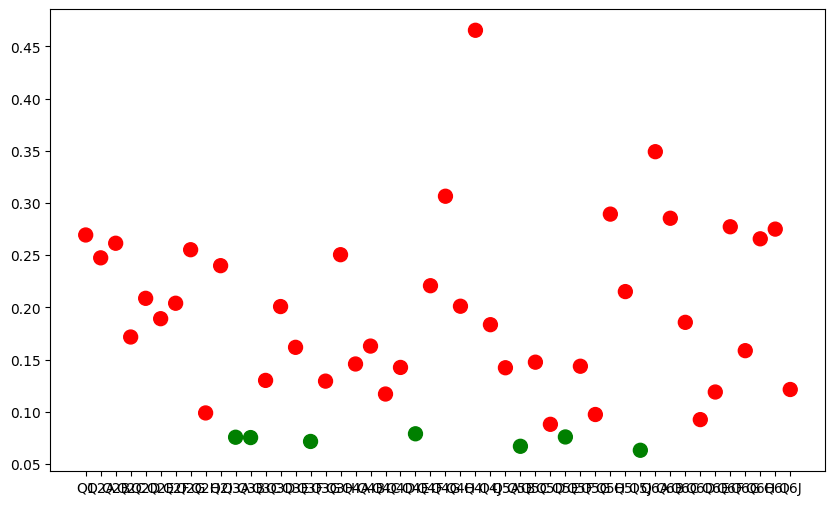

In [125]:
results_df['no_sig_diff'] = results_df['ks_p_mean']  > 0.05
# show in graph which questions had no significant KS
plt.figure(figsize=(10, 6))
plt.scatter(results_df['question'], results_df['ks_D_mean'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))

In [ ]:
# maybe d